In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('C:\\Users\\tytyl\\churn-predictor\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0.5, 1.0, 'Churn Distribution')

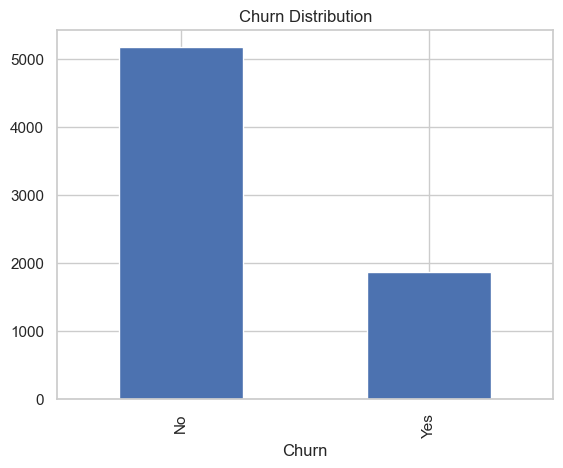

In [ ]:

df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')

Customers churn 26.5% of the time. 


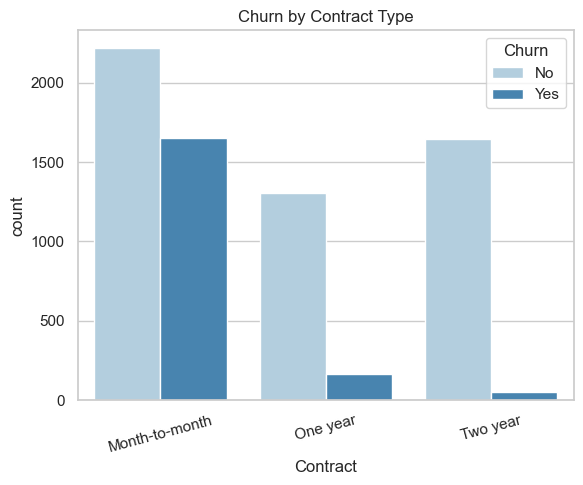

In [5]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='Blues')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

Month to month corntrats
 with customers increases churn signifiantly. 

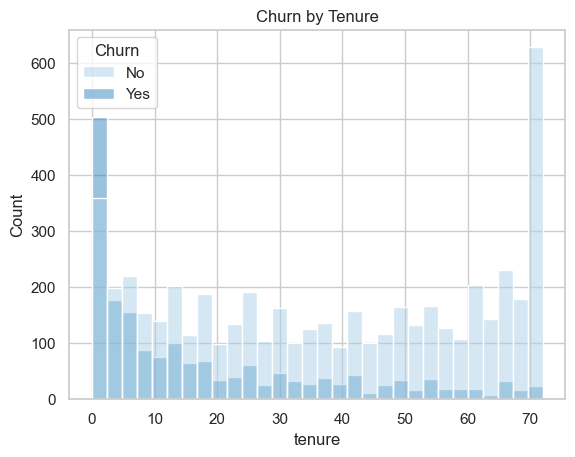

In [6]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Blues')
plt.title('Churn by Tenure')
plt.show()

longer tenured customers tend to churn less. This means that the company is able to get customers to join but has a hard time keeping those who do. 


In [9]:
# Fix TotalCharges column - it's a string, should be numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls that created
print(df['TotalCharges'].isnull().sum())

11


In [10]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [11]:
# CustomerID is just a unique identifier, useless for modeling
df = df.drop(columns=['customerID'])

In [12]:
# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [13]:
# Convert binary Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [14]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [15]:
# These columns have more than 2 categories so we need dummy variables
df = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
], drop_first=True)

print(df.shape)
print(df.dtypes)

(7032, 31)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSuppo

In [16]:
print(df.shape)
print(df.isnull().sum().sum())
print(df.head())

(7032, 31)
0
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False       

In [17]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape)
print(y.value_counts())

(7032, 30)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training rows: {X_train.shape[0]}')
print(f'Testing rows: {X_test.shape[0]}')

Training rows: 5625
Testing rows: 1407


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_pred_lr, y_test))
print(f"AUC Score: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1075
           1       0.57      0.65      0.61       332

    accuracy                           0.80      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.81      0.80      0.81      1407

AUC Score: 0.836


Logistic regression works best for finding linear relationships. It assumes that the features have a clean mathmatical relationship. 

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_pred_rf, y_test))
print(f"AUC Score: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

Random Forest:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1103
           1       0.51      0.62      0.56       304

    accuracy                           0.79      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.81      0.79      0.79      1407

AUC Score: 0.814


Handles complex non-linear patterns well. Very resistant to over-fitting. Tells you what features matter the most. 

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print(classification_report(y_pred_xgb, y_test))
print(f"AUC Score: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.3f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1059
           1       0.55      0.59      0.57       348

    accuracy                           0.78      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407

AUC Score: 0.820


In [23]:
xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_tuned.fit(X_train, y_train)

print(f"XGBoost Tuned AUC: {roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:,1]):.3f}")

XGBoost Tuned AUC: 0.836


C:\Users\tytyl\AppData\Local\Temp\ipykernel_28184\963061020.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


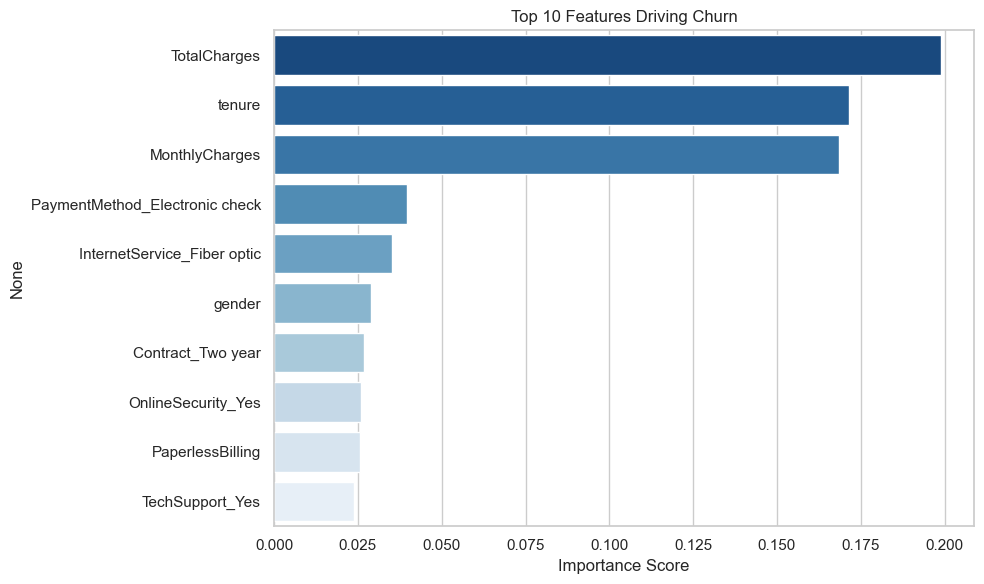

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = df.drop(columns=['Churn']).columns

importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Top 10 Features Driving Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

The most powerful of the 3. Creates a new tree solely based of the mistakes of the tree before it. Go to algorithim for tabular data. 